# Дообучние ViT в 2 этапа + расширенные и улучшенные аугментации

* Качество на тесте: 0.58
* Качество на валидации: 0.84

In [ ]:
import sys

from pathlib import Path
import os
from glob import glob

import pandas as pd
import numpy as np

from PIL import Image

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sneakers_hse.model.baseline_cnn import LitCNN
from sneakers_hse.model.resnet_18 import LitResNet18
from sneakers_hse.model.dataset import ImageDataset
from sneakers_hse.model.streaming_dataset import StreamingImageDataset
from sneakers_hse.model.classifier import LitClassifier

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt

from litdata import optimize
import fsspec

from tqdm import tqdm
tqdm.pandas()

%load_ext autoreload
%autoreload 2

In [2]:
train_df_pre = pd.read_csv('../../data/03_yolo_preprocessed/train_images.csv')
display(train_df_pre.head(), train_df_pre.shape)

test_df = pd.read_csv('../../data/03_yolo_preprocessed/test_images.csv')
display(test_df.head(), test_df.shape)

,Unnamed: 0,path,sneaker_class,corrupted_flg
0,0,Vans Кеды Upland/clothing_0_264.jpeg,Vans Кеды Upland,0
1,1,Vans Кеды Upland/clothing_0_57.jpeg,Vans Кеды Upland,0
2,2,Vans Кеды Upland/orig_45.jpeg,Vans Кеды Upland,0
3,3,Vans Кеды Upland/clothing_0_0.jpeg,Vans Кеды Upland,0
4,4,Vans Кеды Upland/clothing_0_233.jpeg,Vans Кеды Upland,0


(10965, 4)

,Unnamed: 0,path,sneaker_class,corrupted_flg
0,14,Vans Кеды Upland/clothing_0_168_real.jpeg,Vans Кеды Upland,0
1,32,Vans Кеды Upland/clothing_0_215_real.jpeg,Vans Кеды Upland,0
2,44,Vans Кеды Upland/orig_216_real.jpeg,Vans Кеды Upland,0
3,80,Vans Кеды Upland/shoe_3_100_real.jpeg,Vans Кеды Upland,0
4,87,Vans Кеды Upland/clothing_0_277_real.jpeg,Vans Кеды Upland,0


(300, 4)

In [3]:
train_df, val_df = train_test_split(
    train_df_pre,
    test_size=0.2,
    stratify=train_df_pre["sneaker_class"],
    random_state=42
)

display(train_df.head(), train_df.shape)
display(val_df.head(), val_df.shape)
display(test_df.head(), test_df.shape)

,Unnamed: 0,path,sneaker_class,corrupted_flg
2195,2288,Nike Кеды Dunk Low Retro/clothing_0_103.jpeg,Nike Кеды Dunk Low Retro,0
10557,10855,PUMA Кроссовки Puma Morphic/orig_111.jpeg,PUMA Кроссовки Puma Morphic,0
7299,7477,Kari Кроссовки/clothing_0_190.jpeg,Kari Кроссовки,0
4103,4230,Reebok Кроссовки CLASSIC LEATHER/clothing_0_43...,Reebok Кроссовки CLASSIC LEATHER,0
2097,2188,Nike Кеды Dunk Low Retro/clothing_0_86.jpeg,Nike Кеды Dunk Low Retro,0


(8772, 4)

,Unnamed: 0,path,sneaker_class,corrupted_flg
7461,7639,Vans Кеды Knu Skool/clothing_0_98.jpeg,Vans Кеды Knu Skool,0
2486,2591,Reebok Кроссовки CLASSIC NYLON/orig_291.jpeg,Reebok Кроссовки CLASSIC NYLON,0
4889,5027,Nike Кроссовки AIR MAX 90/clothing_0_12.jpeg,Nike Кроссовки AIR MAX 90,0
2655,2762,Under Armour Кроссовки UA CHARGED SPEED SWIFT/...,Under Armour Кроссовки UA CHARGED SPEED SWIFT,0
231,240,Vans Кеды Upland/clothing_0_62.jpeg,Vans Кеды Upland,0


(2193, 4)

,Unnamed: 0,path,sneaker_class,corrupted_flg
0,14,Vans Кеды Upland/clothing_0_168_real.jpeg,Vans Кеды Upland,0
1,32,Vans Кеды Upland/clothing_0_215_real.jpeg,Vans Кеды Upland,0
2,44,Vans Кеды Upland/orig_216_real.jpeg,Vans Кеды Upland,0
3,80,Vans Кеды Upland/shoe_3_100_real.jpeg,Vans Кеды Upland,0
4,87,Vans Кеды Upland/clothing_0_277_real.jpeg,Vans Кеды Upland,0


(300, 4)

In [4]:
train_paths = train_df["path"].tolist()
val_paths   = val_df["path"].tolist()
test_paths  = test_df["path"].tolist()

train_labels = train_df["sneaker_class"].tolist()
val_labels   = val_df["sneaker_class"].tolist()
test_labels  = test_df["sneaker_class"].tolist()

In [5]:
train_tfms = A.Compose([
    A.RandomResizedCrop(
        size=(224, 224),
        scale=(0.7, 1.0),
        ratio=(0.75, 1.33),
        p=1.0
    ),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.0, 0.1),
        rotate=(-15, 15),
        shear=(-10, 10),
        p=0.7
    ),

    A.Perspective(scale=(0.02, 0.08), p=0.5),

    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2
        ),
        A.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05
        ),
    ], p=0.7),

    A.OneOf([
        A.MotionBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=5),
    ], p=0.3),

    A.GaussNoise(std_range=(0.03, 0.08), p=0.3),

    A.CoarseDropout(
        num_holes_range=(1, 2),
        hole_height_range=(11, 34),
        hole_width_range=(11, 34),
        fill=0,
        p=0.5
    ),

    A.ImageCompression(quality_range=(40, 100), p=0.3),

    A.RandomShadow(
        shadow_roi=(0, 0.5, 1, 1),
        num_shadows_limit=(1, 2),
        shadow_intensity_range=(0.3, 0.6),
        p=0.2
    ),

    A.RandomFog(fog_coef_range=(0.1, 0.3), p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

In [6]:
path_to_dataset = '../../data/03_yolo_preprocessed/search-dataset-images'

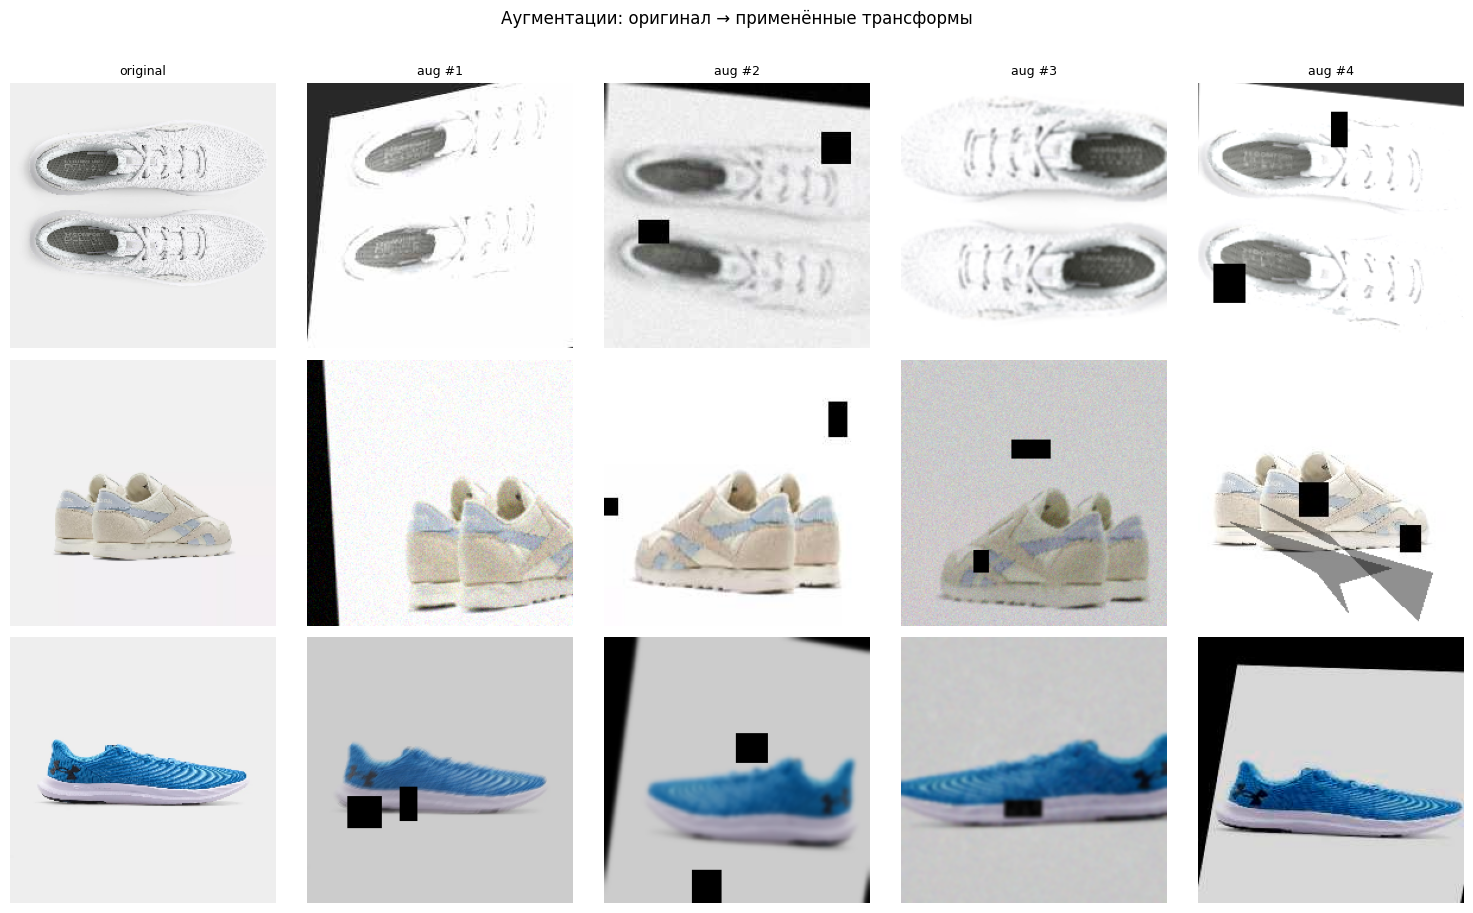

In [7]:
vis_tfms = A.Compose([
    t for t in train_tfms.transforms
    if not isinstance(t, (A.Normalize, ToTensorV2))
])

N_IMAGES = 3
N_AUG = 4

fig, axes = plt.subplots(N_IMAGES, N_AUG + 1, figsize=(3 * (N_AUG + 1), 3 * N_IMAGES))

sample_paths = train_df.sample(N_IMAGES, random_state=7)["path"].tolist()

for row, rel_path in enumerate(sample_paths):
    img = np.array(Image.open(os.path.join(path_to_dataset, rel_path)).convert("RGB"))
    orig = A.Resize(224, 224)(image=img)["image"]

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title("original" if row == 0 else "", fontsize=9)
    axes[row, 0].axis("off")

    for col in range(N_AUG):
        aug = vis_tfms(image=img)["image"]
        axes[row, col + 1].imshow(aug)
        axes[row, col + 1].set_title(f"aug #{col + 1}" if row == 0 else "", fontsize=9)
        axes[row, col + 1].axis("off")

plt.suptitle("Аугментации: оригинал → применённые трансформы", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
all_classes = sorted(set(train_labels + val_labels + test_labels))
class_to_idx = {c: i for i, c in enumerate(all_classes)}

In [9]:
train_dataset = ImageDataset(
    base_path=path_to_dataset,
    images_path=train_paths,
    labels=train_labels,
    augmenter=train_tfms,
    class_to_idx=class_to_idx
)

val_dataset = ImageDataset(
    base_path=path_to_dataset,
    images_path=val_paths,
    labels=val_labels,
    augmenter=val_tfms,
    class_to_idx=class_to_idx
)

test_dataset = ImageDataset(
    base_path=path_to_dataset,
    images_path=test_paths,
    labels=test_labels,
    augmenter=val_tfms,
    class_to_idx=class_to_idx
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=8,
    pin_memory=False,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False,
    persistent_workers=True,
)

In [11]:
callbacks = [
    ModelCheckpoint(
        monitor="val_loss",
        save_top_k=1,
        mode="min"
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3
    )
]

In [ ]:
from sneakers_hse.data.utils.eda_utils import directory_to_dataframe

df = directory_to_dataframe(path_to_dataset)
df.head()

,path,sneaker_class
0,Vans Кеды Upland/clothing_0_264.jpeg,Vans Кеды Upland
1,Vans Кеды Upland/clothing_0_57.jpeg,Vans Кеды Upland
2,Vans Кеды Upland/orig_45.jpeg,Vans Кеды Upland
3,Vans Кеды Upland/clothing_0_0.jpeg,Vans Кеды Upland
4,Vans Кеды Upland/clothing_0_233.jpeg,Vans Кеды Upland


In [13]:
# # обучаем голову

# model = LitClassifier(
#     model_name="efficientformer_l1",
#     num_classes=df["sneaker_class"].nunique(),
#     lr=1e-3,
#     freeze_backbone=True
# )

# trainer = pl.Trainer(
#     max_epochs=5,
#     callbacks=callbacks
# )

# trainer.fit(model, train_loader, val_loader)

In [14]:
# torch.save(model.state_dict(), "../../models/head_final_fixed_augmented_efficientformer_l1.pth")

In [15]:
model = LitClassifier(
      model_name="efficientformer_l1",                                                                                                                             
      num_classes=df["sneaker_class"].nunique(),                                                                                                                   
      lr=1e-3,                                  
      freeze_backbone=True,                                                                                                                                        
)
                        
model.load_state_dict(torch.load('../../models/head_final_fixed_augmented_efficientformer_l1.pth'))

<All keys matched successfully>

In [16]:
# уменьшаем lr и дообучаем все

model.unfreeze()
model.lr = 1e-4

trainer = pl.Trainer(
    max_epochs=10,
    callbacks=callbacks
)

trainer.fit(model, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ EfficientFormer  │ 11.4 M │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.4 M                                                                                               
Total estimated model params size (MB): 45                                                                         
Modules in train mode: 246                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=10` reached.


In [17]:
model.eval()

pred_batches = trainer.predict(model, dataloaders=test_loader)
probs = torch.cat(pred_batches)

y_pred = probs.argmax(dim=1).cpu().numpy()

y_true = []
for _, y in test_loader:
    y_true.append(y)
y_true = torch.cat(y_true).cpu().numpy()

print(classification_report(y_true, y_pred))

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           3       1.00      0.80      0.89         5
           4       1.00      0.83      0.91         6
           5       0.67      1.00      0.80         2
           6       0.67      1.00      0.80         4
           7       0.50      1.00      0.67         1
           8       1.00      0.83      0.91         6
          10       0.50      0.50      0.50         6
          11       0.25      0.50      0.33         2
          12       0.90      0.90      0.90        10
          13       0.62      0.83      0.71         6
          14       1.00      0.75      0.86         4
          15       0.75      0.75      0.75        12
          16       1.00      0.38      0.55         8
          17       1.00      0.62      0.77        16
          18       0.60      0.75      0.67         4
          19       0.59    

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [18]:
torch.save(model.state_dict(), "../../models/final_fixed_augmented_efficientformer_l1.pth")

In [19]:
model.eval()

pred_batches = trainer.predict(model, dataloaders=val_loader)
probs = torch.cat(pred_batches)

y_pred = probs.argmax(dim=1).cpu().numpy()

y_true = []
for _, y in val_loader:
    y_true.append(y)
y_true = torch.cat(y_true).cpu().numpy()

print(classification_report(y_true, y_pred))

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

              precision    recall  f1-score   support

           0       0.69      0.70      0.70        54
           1       0.84      0.89      0.86        54
           2       0.85      0.83      0.84        54
           3       0.87      0.82      0.84        56
           4       1.00      0.93      0.96        56
           5       0.96      0.94      0.95        54
           6       0.92      0.93      0.92        58
           7       0.95      1.00      0.97        57
           8       0.93      0.94      0.94        54
           9       0.98      0.95      0.96        56
          10       0.86      0.96      0.91        53
          11       0.98      0.91      0.94        53
          12       0.96      0.95      0.95        56
          13       0.94      0.87      0.91        55
          14       0.94      0.96      0.95        52
          15       0.92      0.92      0.92        50
          16       0.88      0.95      0.91        55
          17       0.96    